# Project 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy.linalg import expm
from scipy.stats import kstest
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp


## Part 1

### Task 1

Proportion of women with local recurrence: 0.7120
Average simulated lifetime: 22.09 years


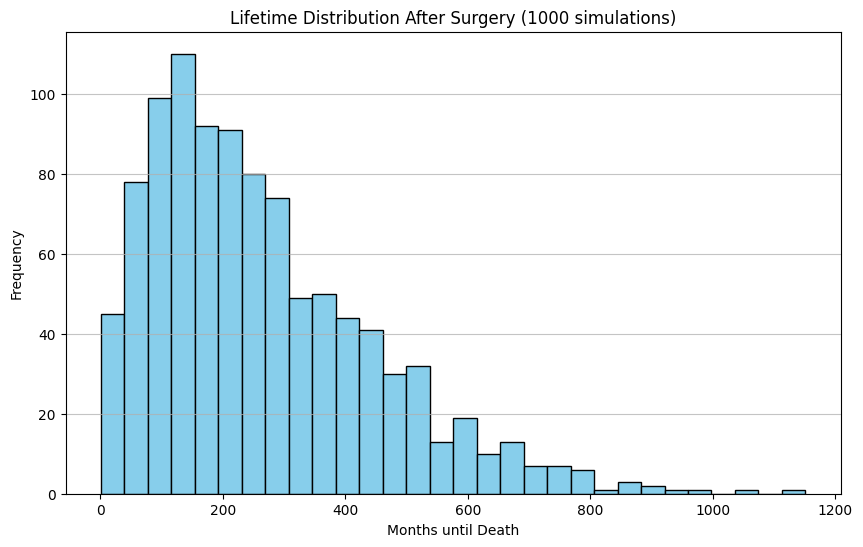

In [3]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
              [0, 0.986, 0.005, 0.004, 0.005],
              [0, 0, 0.992, 0.003, 0.005],
              [0, 0, 0, 0.991, 0.009],
              [0, 0, 0, 0, 1]])


state_labels = ["State 1 (Post-surgery)", "State 2 (Local Recurrence)", "State 3 (Distant Metastasis)", "State 4 (Both Recurrence)", "State 5 (Death)"]

num_women = 1000
lifetimes = []
local_recurrence_count = 0

np.random.seed(42)

for _ in range(num_women):
    state = 0 
    months = 0
    had_local = False
    
    while state != 4: 
        if state == 1 or state == 3:
            had_local = True
            
        state = np.random.choice(5, p=P[state])
        months += 1
        
    lifetimes.append(months)
    if had_local:
        local_recurrence_count += 1

proportion_local = local_recurrence_count / num_women
print(f"Proportion of women with local recurrence: {proportion_local:.4f}")
print(f"Average simulated lifetime: {np.mean(lifetimes)/12:.2f} years")

plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=30, color='skyblue', edgecolor='black')
plt.title('Lifetime Distribution After Surgery (1000 simulations)')
plt.xlabel('Months until Death')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.savefig("lifetime_distribution.png")

### Task 2

In [4]:
random.seed(42)
np.random.seed(42)

n = 1000
def simulate_state_at_t(P, t_max=120, start_state=0):
    state = start_state
    for _ in range(t_max):
        state = np.random.choice(len(P), p=P[state])
    return state

def simulate_states_at_120(P, n):
    states = []
    for _ in range(n):
        s = simulate_state_at_t(P, t_max=120)
        states.append(s)
    return np.array(states)

In [5]:
random.seed(42)
np.random.seed(42)

states_120 = simulate_states_at_120(P, n)

counts = np.bincount(states_120, minlength=5)
empirical_dist = counts / 1000
print("Empirical distribution at t=120:", empirical_dist)

p0 = np.array([1, 0, 0, 0, 0])
P120 = np.linalg.matrix_power(P, 120)
theoretical_dist = p0 @ P120
print("Theoretical distribution at t=120:", theoretical_dist)

expected_counts = 1000 * theoretical_dist
chi2, p_value = chisquare(counts, expected_counts)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)


Empirical distribution at t=120: [0.357 0.164 0.184 0.061 0.234]
Theoretical distribution at t=120: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
Chi-square statistic: 3.585606013711987
p-value: 0.4649816886570908


### Task 3

--- Mean Lifetime Comparison ---
Empirical Mean (Simulation): 265.04 months
Theoretical Mean E(T):       262.37 months


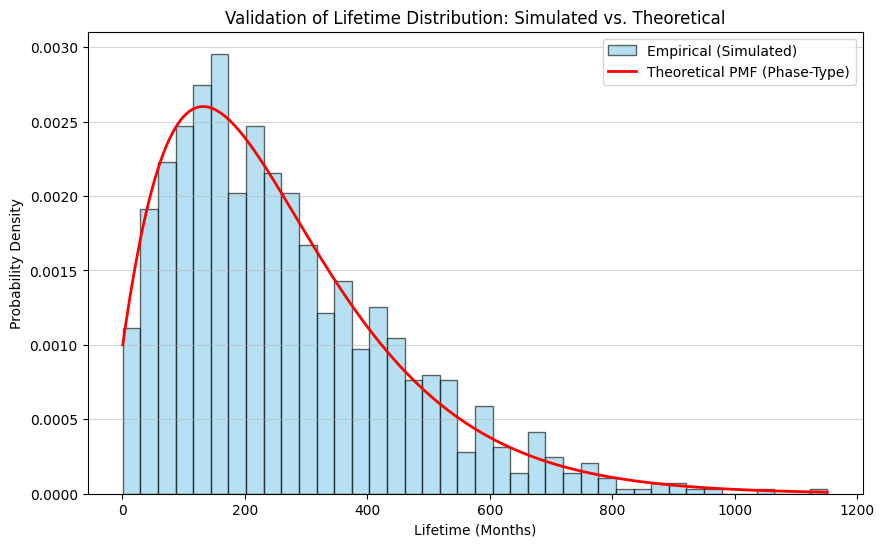

In [6]:
np.random.seed(42)

num_women = 1000
lifetimes = []

for _ in range(num_women):
    current_state = 0
    lifetime_months = 0
    while current_state != 4:
        current_state = np.random.choice(5, p=P[current_state])
        lifetime_months += 1
    lifetimes.append(lifetime_months)

empirical_mean = np.mean(lifetimes)
pi = np.array([1, 0, 0, 0]) 
P_s = P[0:4, 0:4]
p_s = P[0:4, 4]
I = np.eye(4)
ones = np.ones(4)

inverse_matrix = np.linalg.inv(I - P_s)
theoretical_mean = pi @ inverse_matrix @ ones

print("--- Mean Lifetime Comparison ---")
print(f"Empirical Mean (Simulation): {empirical_mean:.2f} months")
print(f"Theoretical Mean E(T):       {theoretical_mean:.2f} months")

max_t = max(lifetimes)
t_values = np.arange(1, max_t + 1)
theoretical_pmf = []

for t in t_values:
    P_s_power_t_minus_1 = np.linalg.matrix_power(P_s, t - 1)
    prob_t = pi @ P_s_power_t_minus_1 @ p_s
    theoretical_pmf.append(prob_t)

theoretical_pmf = np.array(theoretical_pmf)

plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=40, density=True, color='skyblue', edgecolor='black', alpha=0.6, label='Empirical (Simulated)')
plt.plot(t_values, theoretical_pmf, color='red', linewidth=2, label='Theoretical PMF (Phase-Type)')

plt.title('Validation of Lifetime Distribution: Simulated vs. Theoretical')
plt.xlabel('Lifetime (Months)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.savefig("lifetime_comparison.png")
plt.show()

In [7]:
num_women = 1000 
lifetimes = []
np.random.seed(42) 
for _ in range(num_women):
    current_state = 0
    lifetime_months = 0
    while current_state != 4:
        current_state = np.random.choice(5, p=P[current_state])
        lifetime_months += 1
    lifetimes.append(lifetime_months)

pi = np.array([1, 0, 0, 0]) 
P_s = P[0:4, 0:4]
ones = np.ones(4)


bin_edges = [0, 24, 48, 72, 96, 120, 144, 168, 192, 216, 240, 300, 400, float('inf')]

observed_counts, _ = np.histogram(lifetimes, bins=bin_edges)

def calculate_cdf(t):
    if t == 0:
        return 0.0
    if t == float('inf'):
        return 1.0
    return 1.0 - (pi @ np.linalg.matrix_power(P_s, int(t)) @ ones)

expected_probs = []
for i in range(len(bin_edges) - 1):
    lower_bound = bin_edges[i]
    upper_bound = bin_edges[i+1]
    
    prob = calculate_cdf(upper_bound) - calculate_cdf(lower_bound)
    expected_probs.append(prob)

expected_counts = np.array(expected_probs) * num_women

valid_indices = expected_counts > 0
f_obs_valid = observed_counts[valid_indices]
f_exp_valid = expected_counts[valid_indices]

chi_stat, p_value = chisquare(f_obs=f_obs_valid, f_exp=f_exp_valid)

print("--- Data Bins ---")
for i in range(len(bin_edges) - 1):
    print(f"Months {bin_edges[i]:3} to {str(bin_edges[i+1]):<4}: Observed = {observed_counts[i]:3}, Expected = {expected_counts[i]:.1f}")

print("\n--- Chi-Square Test Results ---")
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("The simulated lifetimes follow the theoretical discrete phase-type distribution.")
else:
    print("Conclusion: We reject the null hypothesis.")
    print("The simulated lifetimes significantly deviate from the theoretical distribution.")

--- Data Bins ---
Months   0 to 24  : Observed =  21, Expected = 31.4
Months  24 to 48  : Observed =  40, Expected = 44.0
Months  48 to 72  : Observed =  54, Expected = 52.9
Months  72 to 96  : Observed =  57, Expected = 58.5
Months  96 to 120 : Observed =  59, Expected = 61.5
Months 120 to 144 : Observed =  66, Expected = 62.4
Months 144 to 168 : Observed =  73, Expected = 61.6
Months 168 to 192 : Observed =  53, Expected = 59.7
Months 192 to 216 : Observed =  55, Expected = 56.9
Months 216 to 240 : Observed =  56, Expected = 53.5
Months 240 to 300 : Observed = 119, Expected = 116.9
Months 300 to 400 : Observed = 129, Expected = 142.0
Months 400 to inf : Observed = 218, Expected = 198.9

--- Chi-Square Test Results ---
Chi-square statistic: 10.2425
P-value: 0.5947
Conclusion: We fail to reject the null hypothesis.
The simulated lifetimes follow the theoretical discrete phase-type distribution.


### Task 4

In [8]:
random.seed(42)
np.random.seed(42)

def simulate_one_with_recurrence(P, start_state=0):
    state = start_state
    months = 0
    recurrence_time = None  # tidspunkt for første recidiv

    while state != 4:  # 4 = death
        # registrér recidiv (lokal = 1, regional = 2, distant = 3)
        if recurrence_time is None and state in [1, 2, 3]:
            recurrence_time = months

        # næste måned
        state = np.random.choice(len(P), p=P[state])
        months += 1

    return months, recurrence_time

def estimate_lifetime_given_conditions(P, target_n):
    accepted_lifetimes = []

    while len(accepted_lifetimes) < target_n:
        lifetime, rec_time = simulate_one_with_recurrence(P)

        alive_after_12 = lifetime > 12
        recurrence_within_12 = (rec_time is not None and rec_time <= 12)

        if alive_after_12 and recurrence_within_12:
            accepted_lifetimes.append(lifetime)

    return np.array(accepted_lifetimes)


Estimated expected lifetime: 178.715
Mean lifetime: 178.715
95% CI: [ 169.16054324749567 , 188.26945675250434 ]


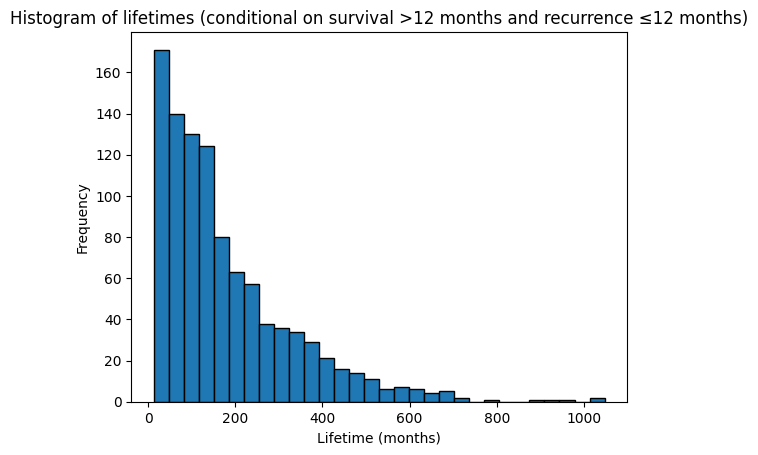

In [9]:
random.seed(42)
np.random.seed(42)

accepted = estimate_lifetime_given_conditions(P, target_n=1000)
expected_lifetime = accepted.mean()

print("Estimated expected lifetime:", expected_lifetime)

mean_est = np.mean(accepted)
std_est = np.std(accepted, ddof=1)
n = len(accepted)

ci_low = mean_est - 1.96 * std_est / np.sqrt(n)
ci_high = mean_est + 1.96 * std_est / np.sqrt(n)

print("Mean lifetime:", mean_est)
print("95% CI: [", ci_low, ",", ci_high, "]")


plt.hist(accepted, bins=30, edgecolor='black')
plt.xlabel("Lifetime (months)")
plt.ylabel("Frequency")
plt.title("Histogram of lifetimes (conditional on survival >12 months and recurrence ≤12 months)")
plt.show()

### Task 5

In [10]:
np.random.seed(42)
pi = np.array([1, 0, 0, 0])
P_s = P[0:4, 0:4]
I = np.eye(4)
ones = np.ones(4)

true_mean = pi @ np.linalg.inv(I - P_s) @ ones

n_women = 200
n_reps = 100

Y_crude = np.zeros(n_reps)
X_control = np.zeros(n_reps)

for i in range(n_reps):
    lifetimes = np.zeros(n_women)
    
    for j in range(n_women):
        current_state = 0
        t = 0
        while current_state != 4:
            current_state = np.random.choice(5, p=P[current_state])
            t += 1
        lifetimes[j] = t
        
    Y_crude[i] = np.sum(lifetimes <= 350) / n_women
    X_control[i] = np.mean(lifetimes)

crude_mean = np.mean(Y_crude)
crude_var = np.var(Y_crude, ddof=1)

covariance_matrix = np.cov(X_control, Y_crude)
var_x = covariance_matrix[0, 0]
cov_xy = covariance_matrix[0, 1]

c_star = cov_xy / var_x
Y_cv = Y_crude - c_star * (X_control - true_mean)

cv_mean = np.mean(Y_cv)
cv_var = np.var(Y_cv, ddof=1)

variance_reduction = ((crude_var - cv_var) / crude_var) * 100

print("\n--- Results ---")
print(f"Crude MC Estimator Mean: {crude_mean:.4f}")
print(f"Crude MC Variance:       {crude_var:.6f}")
print(f"-----------------------------------")
print(f"Control Variate Mean:    {cv_mean:.4f}")
print(f"Control Variate Variance:{cv_var:.6f}")
print(f"-----------------------------------")
print(f"Variance Reduction:      {variance_reduction:.2f}%")


--- Results ---
Crude MC Estimator Mean: 0.7375
Crude MC Variance:       0.001301
-----------------------------------
Control Variate Mean:    0.7371
Control Variate Variance:0.000309
-----------------------------------
Variance Reduction:      76.25%


## Part 2

### Task 7

--- Continuous-Time Simulation Summary ---
Mean Lifetime:         256.37 months | 95% CI: (244.31, 268.43)
Standard Deviation:    194.38 months | 95% CI: (186.22, 203.29)
Proportion with distant metastasis at 30.5 months: 0.0840


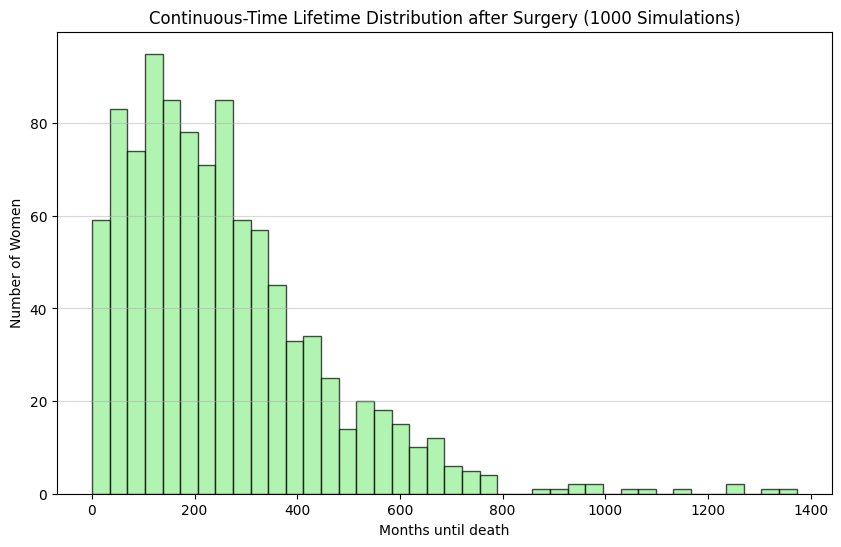

In [11]:
np.random.seed(42)  # For reproducibility

Q = np.array([
    [-0.0085, 0.005, 0.0025, 0,     0.001],
    [0,      -0.014, 0.005,  0.004, 0.005],
    [0,      0,     -0.008,  0.003, 0.005],
    [0,      0,     0,      -0.009, 0.009],
    [0,      0,     0,      0,     0]
])


num_women = 1000
lifetimes = []
distant_metastasis_at_305 = 0

for _ in range(num_women):
    current_state = 0 
    current_time = 0.0
    had_distant_metastasis_by_305 = False
    
    while current_state != 4:
        rate = -Q[current_state, current_state]
        
        sojourn_time = np.random.exponential(1.0 / rate)
        
        if current_state == 2 or current_state == 3:
            if current_time <= 30.5:
                had_distant_metastasis_by_305 = True
        elif current_time < 30.5 and (current_time + sojourn_time) >= 30.5:
            if current_state == 2 or current_state == 3:
                had_distant_metastasis_by_305 = True

        current_time += sojourn_time
        
        row_rates = np.copy(Q[current_state, :])
        row_rates[current_state] = 0 
        probabilities = row_rates / rate
        
        current_state = np.random.choice(5, p=probabilities)
        
    lifetimes.append(current_time)
    if had_distant_metastasis_by_305:
        distant_metastasis_at_305 += 1

lifetimes = np.array(lifetimes)

mean_lifetime = np.mean(lifetimes)
std_lifetime = np.std(lifetimes, ddof=1)

mean_se = std_lifetime / np.sqrt(num_women)
mean_ci = stats.t.interval(0.95, df=num_women-1, loc=mean_lifetime, scale=mean_se)

chi2_lower = stats.chi2.ppf(0.025, df=num_women-1)
chi2_upper = stats.chi2.ppf(0.975, df=num_women-1)
std_ci_lower = np.sqrt((num_women - 1) * (std_lifetime**2) / chi2_upper)
std_ci_upper = np.sqrt((num_women - 1) * (std_lifetime**2) / chi2_lower)

proportion_distant_305 = distant_metastasis_at_305 / num_women

print("--- Continuous-Time Simulation Summary ---")
print(f"Mean Lifetime:         {mean_lifetime:.2f} months | 95% CI: ({mean_ci[0]:.2f}, {mean_ci[1]:.2f})")
print(f"Standard Deviation:    {std_lifetime:.2f} months | 95% CI: ({std_ci_lower:.2f}, {std_ci_upper:.2f})")
print(f"Proportion with distant metastasis at 30.5 months: {proportion_distant_305:.4f}")

plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Continuous-Time Lifetime Distribution after Surgery (1000 Simulations)')
plt.xlabel('Months until death')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.5)
plt.savefig("continuous_time_lifetime_distribution.png")
plt.show()

### Task 8

--- Continuous Validation: K-S Test ---
K-S Statistic: 0.0240
P-value:       0.9358
Conclusion: We fail to reject the null hypothesis.
The empirical lifetime distribution matches the theoretical continuous phase-type distribution.


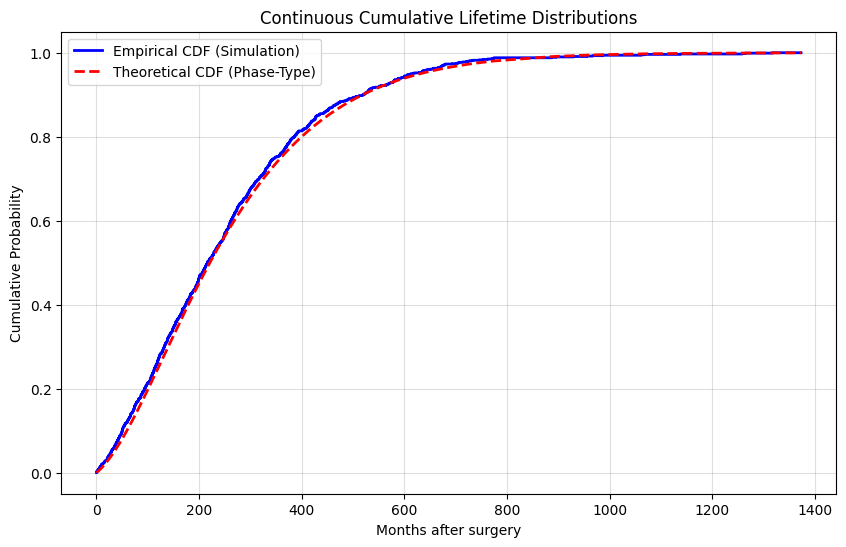

In [12]:
np.random.seed(42)
Q_s = Q[0:4, 0:4]
pi_0 = np.array([1, 0, 0, 0])
ones = np.ones(4)

num_women = 1000
simulated_lifetimes = []

for _ in range(num_women):
    current_state = 0
    current_time = 0.0
    while current_state != 4:
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(1.0 / rate)
        current_time += sojourn_time
        
        row_rates = np.copy(Q[current_state, :])
        row_rates[current_state] = 0
        probabilities = row_rates / rate
        current_state = np.random.choice(5, p=probabilities)
        
    simulated_lifetimes.append(current_time)

simulated_lifetimes = np.sort(simulated_lifetimes)

theoretical_cdf_vals = []
for t in simulated_lifetimes:
    matrix_exponential = expm(Q_s * t)
    cdf_t = 1.0 - (pi_0 @ matrix_exponential @ ones)
    theoretical_cdf_vals.append(cdf_t)

theoretical_cdf_vals = np.array(theoretical_cdf_vals)

empirical_cdf_vals = np.arange(1, num_women + 1) / num_women
ks_stat, p_value = ks_2samp(empirical_cdf_vals, theoretical_cdf_vals)

print("--- Continuous Validation: K-S Test ---")
print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value:       {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("The empirical lifetime distribution matches the theoretical continuous phase-type distribution.")
else:
    print("Conclusion: We reject the null hypothesis.")
    print("There is a significant difference between the simulation and theory.")

plt.figure(figsize=(10, 6))
plt.step(simulated_lifetimes, empirical_cdf_vals, label='Empirical CDF (Simulation)', color='blue', linewidth=2)
plt.plot(simulated_lifetimes, theoretical_cdf_vals, label='Theoretical CDF (Phase-Type)', color='red', linestyle='--', linewidth=2)

plt.title('Continuous Cumulative Lifetime Distributions')
plt.xlabel('Months after surgery')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig("continuous_cdf_comparison.png")
plt.show()

### Task 9

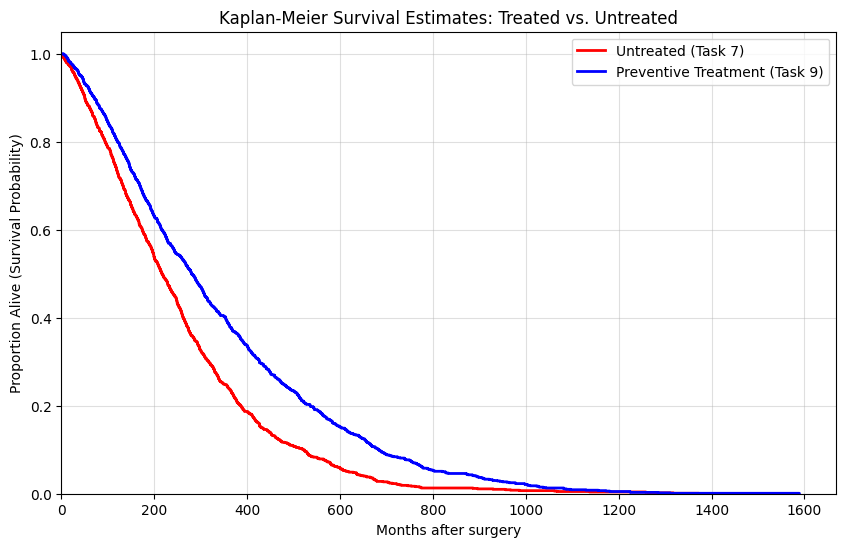


Mean Lifetime (Untreated): 256.37 months
Mean Lifetime (Treated):   338.45 months


In [13]:
np.random.seed(42)
Q_untreated = np.array([
    [-0.0085,  0.005,   0.0025,  0,       0.001],
    [ 0,      -0.014,   0.005,   0.004,   0.005],
    [ 0,       0,      -0.008,   0.003,   0.005],
    [ 0,       0,       0,      -0.009,   0.009],
    [ 0,       0,       0,       0,       0.0  ]
])

Q_treated = np.array([
    [-0.00475, 0.0025, 0.00125, 0,     0.001],
    [ 0,      -0.007,  0,       0.002, 0.005],
    [ 0,       0,     -0.008,   0.003, 0.005],
    [ 0,       0,      0,      -0.009, 0.009],
    [ 0,       0,      0,       0,     0.0  ]
])

num_women = 1000

def simulate_ctmc(Q, num_patients):
    lifetimes = np.zeros(num_patients)
    
    for i in range(num_patients):
        current_state = 0
        current_time = 0.0
        
        while current_state != 4:
            rate = -Q[current_state, current_state]
            sojourn_time = np.random.exponential(1.0 / rate)
            current_time += sojourn_time
            
            row_rates = np.copy(Q[current_state, :])
            row_rates[current_state] = 0
            probabilities = row_rates / rate
            
            current_state = np.random.choice(5, p=probabilities)
            
        lifetimes[i] = current_time
        
    return np.sort(lifetimes)

lifetimes_untreated = simulate_ctmc(Q_untreated, num_women)
lifetimes_treated = simulate_ctmc(Q_treated, num_women)

survival_probs = 1.0 - (np.arange(1, num_women + 1) / num_women)

t_untreated = np.insert(lifetimes_untreated, 0, 0)
t_treated = np.insert(lifetimes_treated, 0, 0)
s_probs = np.insert(survival_probs, 0, 1.0)

plt.figure(figsize=(10, 6))
plt.step(t_untreated, s_probs, where='post', label='Untreated (Task 7)', color='red', linewidth=2)
plt.step(t_treated, s_probs, where='post', label='Preventive Treatment (Task 9)', color='blue', linewidth=2)

plt.title('Kaplan-Meier Survival Estimates: Treated vs. Untreated')
plt.xlabel('Months after surgery')
plt.ylabel('Proportion Alive (Survival Probability)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.xlim(left=0)
plt.ylim(0, 1.05)
plt.savefig("kaplan_meier_comparison.png")
plt.show()

print(f"\nMean Lifetime (Untreated): {np.mean(lifetimes_untreated):.2f} months")
print(f"Mean Lifetime (Treated):   {np.mean(lifetimes_treated):.2f} months")

### Task 10

In [14]:
all_times = np.sort(np.unique(np.concatenate([lifetimes_untreated, lifetimes_treated])))
O1 = np.array([(lifetimes_untreated == t).sum() for t in all_times])
O2 = np.array([(lifetimes_treated    == t).sum() for t in all_times])

R1 = np.array([(lifetimes_untreated >= t).sum() for t in all_times])
R2 = np.array([(lifetimes_treated    >= t).sum() for t in all_times])
R  = R1 + R2
O  = O1 + O2

mask = R > 0
E1   = (R1[mask] / R[mask]) * O[mask]

U = (O1[mask] - E1).sum()
V = ((R1[mask] * R2[mask] * O[mask] * (R[mask] - O[mask])) /
     (R[mask]**2 * (R[mask] - 1).clip(min=1))).sum()

logrank_stat = U**2 / V
logrank_p    = stats.chi2.sf(logrank_stat, df=1)

print(f"Log-rank test")
print(f"  chi2 = {logrank_stat:.4f},  p-value = {logrank_p:.4e}")
if logrank_p < 0.05:
    print("  Reject H0: survival functions differ significantly.")
else:
    print("  Fail to reject H0: no significant difference.")


Log-rank test
  chi2 = 67.6457,  p-value = 1.9568e-16
  Reject H0: survival functions differ significantly.


## 3

### Task 12

In [27]:
Q = np.array([
    [-0.0085,  0.005,   0.0025,  0,       0.001],
    [ 0,      -0.014,   0.005,   0.004,   0.005],
    [ 0,       0,      -0.008,   0.003,   0.005],
    [ 0,       0,       0,      -0.009,   0.009],
    [ 0,       0,       0,       0,       0.0  ]
])

np.random.seed(42)
num_women = 1000
observation_interval = 48.0
observed_data = []

for _ in range(num_women):
    current_state = 0 
    current_time = 0.0
    target_time = 0.0
    time_series = []
    
    while current_state != 4:
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(1.0 / rate)
        next_transition_time = current_time + sojourn_time
        
        while target_time < next_transition_time:
            time_series.append(current_state)
            target_time += observation_interval
            
        current_time = next_transition_time
        row_probs = np.copy(Q[current_state, :])
        row_probs[current_state] = 0
        row_probs /= rate
        current_state = np.random.choice(5, p=row_probs)
        
    time_series.append(4)
    observed_data.append(time_series)

lengths = [len(ts) for ts in observed_data]
print(f"Generated {len(observed_data)} time series.")
print(f"Length (# observations): min={min(lengths)}, max={max(lengths)}\n")

for i in range(5):
    display_series = [state + 1 for state in observed_data[i]]
    final_obs_month = (len(display_series) - 1) * int(observation_interval)
    print(f"Woman {i+1}: {display_series}")
    print(f"          -> Death observed at month {final_obs_month}\n")

Generated 1000 time series.
Length (# observations): min=2, max=30

Woman 1: [1, 1, 5]
          -> Death observed at month 96

Woman 2: [1, 1, 1, 1, 5]
          -> Death observed at month 192

Woman 3: [1, 1, 1, 5]
          -> Death observed at month 144

Woman 4: [1, 1, 1, 1, 1, 3, 5]
          -> Death observed at month 288

Woman 5: [1, 1, 2, 3, 4, 4, 5]
          -> Death observed at month 288



### Task 13

In [26]:
def simulate_segment(Q_cur, start_state, end_state, duration, max_tries=50000):
    n_states = Q_cur.shape[0]
    for _ in range(max_tries):
        Nij = np.zeros((n_states, n_states))
        Si  = np.zeros(n_states)
        state = start_state
        t = 0.0

        while True:
            rate = -Q_cur[state, state]
            if rate == 0:
                break
            sojourn = np.random.exponential(1.0 / rate)

            if t + sojourn >= duration:
                Si[state] += duration - t
                break
            else:
                Si[state] += sojourn
                t += sojourn
                off = Q_cur[state].copy(); off[state] = 0.0
                next_s = np.random.choice(n_states, p=off / off.sum())
                Nij[state, next_s] += 1
                state = next_s

        if state == end_state:
            return Nij, Si
    return None

def mcem_update(Q_cur, time_series, obs_interval):
    n_states = Q_cur.shape[0]
    Nij_total = np.zeros((n_states, n_states))
    Si_total  = np.zeros(n_states)

    for ts in time_series:
        for k in range(len(ts) - 1):
            s_start = ts[k]
            s_end   = ts[k + 1]

            if s_start == 4:
                break

            result = simulate_segment(Q_cur, s_start, s_end, obs_interval)
            if result is None:
                continue
            Nij, Si = result
            Nij_total += Nij
            Si_total  += Si

    Q_new = np.zeros_like(Q_cur)
    for i in range(n_states - 1):
        for j in range(n_states):
            if i != j and Si_total[i] > 0:
                Q_new[i, j] = Nij_total[i, j] / Si_total[i]
        Q_new[i, i] = -Q_new[i].sum()

    return Q_new

Q_init = np.array([
    [-0.010, 0.006,  0.003,  0,      0.001 ],
    [ 0,    -0.016,  0.006,  0.005,  0.005 ],
    [ 0,     0,     -0.010,  0.004,  0.006 ],
    [ 0,     0,      0,     -0.012,  0.012 ],
    [ 0,     0,      0,      0,      0     ]
])

np.random.seed(42)
Q_cur  = Q_init.copy()
tol    = 1e-3
max_iter = 30
history = [Q_cur.copy()]

for iteration in range(max_iter):
    Q_new = mcem_update(Q_cur, observed_data, observation_interval)
    diff  = np.max(np.abs(Q_new - Q_cur))
    Q_cur = Q_new
    history.append(Q_cur.copy())
    print(f"Iter {iteration+1:2d}: diff = {diff:.6f}")
    print(Q_cur)
    if diff < tol:
        print("Converged.")
        break

print(f"\nTrue Q:\n{Q}")
print(f"\nEstimated Q:\n{Q_cur.round(5)}")

Iter  1: diff = 0.002016
[[-0.00850381  0.0051448   0.00243209  0.          0.00092691]
 [ 0.         -0.01488975  0.00612818  0.0041839   0.00457767]
 [ 0.          0.         -0.00869768  0.00321895  0.00547873]
 [ 0.          0.          0.         -0.00998402  0.00998402]
 [ 0.          0.          0.          0.          0.        ]]
Iter  2: diff = 0.000507
[[-0.00850767  0.00501102  0.00251827  0.          0.00097838]
 [ 0.         -0.01458482  0.00562097  0.00393716  0.00502669]
 [ 0.          0.         -0.00848402  0.00313082  0.00535321]
 [ 0.          0.          0.         -0.00958632  0.00958632]
 [ 0.          0.          0.          0.          0.        ]]
Converged.

True Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]

Estimated Q:
[[-0.00851  0.00501  0.00252  0.       0.00098]
 [ 0.      -0.01458 